# GLIMT Crowd Alignment Report

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_active_ifps_with_crowd_alignment import get_active_ifps_with_crowd_alignment

In [3]:
df, ifps, id_to_ifp = get_active_ifps_with_crowd_alignment([463, 468, 476, 489])

200


In [9]:
prior = {463: 0.55825, 468: 0.83625, 476: 0.409042, 489: 0.604958}

In [10]:
df

,id,title,distance
0,463,When will Russia cease active military hostilities against Ukraine?,0.293904
2,476,When will Syria's new government terminate the agreements with Russia to use Syrian territory for military bases?,0.475921
3,489,When will a bilateral ceasefire or peace agreement in the Russo-Ukraine conflict first go into effect?,0.524663
1,468,When will Russia be able to fully access its frozen foreign exchange reserves?,0.758944


In [11]:
df['prior'] = df['id'].apply(lambda x: prior[x])

In [13]:
df['improvement'] = df['prior'] - df['distance']

In [14]:
df

,id,title,distance,prior,improvement
0,463,When will Russia cease active military hostilities against Ukraine?,0.293904,0.558250,0.264346
2,476,When will Syria's new government terminate the agreements with Russia to use Syrian territory for military bases?,0.475921,0.409042,-0.066879
3,489,When will a bilateral ceasefire or peace agreement in the Russo-Ukraine conflict first go into effect?,0.524663,0.604958,0.080295
1,468,When will Russia be able to fully access its frozen foreign exchange reserves?,0.758944,0.836250,0.077306


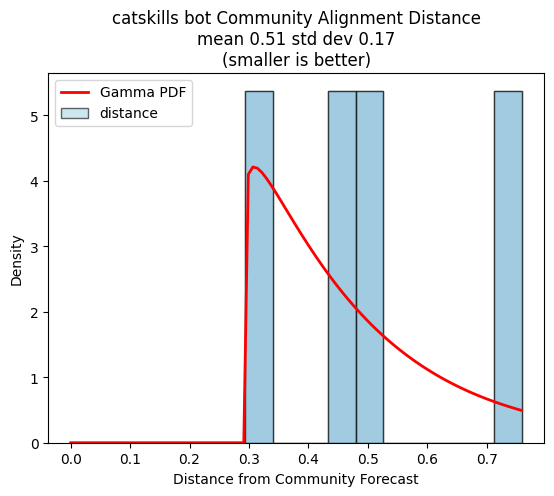

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
distances = df['distance'].values
mean = np.mean(distances)
std = np.std(distances)
params = gamma.fit(distances)
x = np.linspace(0, distances.max(), 100)
pdf = gamma.pdf(x, *params)
plt.hist(distances, bins=10, density=True, alpha=0.5, edgecolor='black')
plt.plot(x, pdf, 'r-', lw=2, label='Gamma PDF')
df['distance'].plot.hist(bins=10, density=True, alpha=0.6, edgecolor='black', color='lightblue')
plt.xlabel('Distance from Community Forecast')
plt.ylabel('Density')
plt.title(f'catskills bot Community Alignment Distance\nmean {mean:0.2f} std dev {std:0.2f}\n(smaller is better)')
plt.legend()
plt.show()

In [8]:
df

,id,title,distance
0,463,When will Russia cease active military hostilities against Ukraine?,0.293904
2,476,When will Syria's new government terminate the agreements with Russia to use Syrian territory for military bases?,0.475921
3,489,When will a bilateral ceasefire or peace agreement in the Russo-Ukraine conflict first go into effect?,0.524663
1,468,When will Russia be able to fully access its frozen foreign exchange reserves?,0.758944
